In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import math
import re
import base64
from collections import Counter
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
# from sklearn.model_selection import ParameterGrid
# from itertools import product
# from tqdm.auto import tqdm
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report, confusion_matrix, accuracy_score, roc_auc_score, roc_curve, auc, precision_recall_curve, average_precision_score, average_precision_score
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l1_l2
from tensorflow.keras.optimizers import Adam

2026-06-22 14:38:46.113522: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782139126.257265      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782139126.301814      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782139126.660328      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782139126.660359      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782139126.660361      57 computation_placer.cc:177] computation placer alr

In [2]:
# =============================================================================
# SECTION 2 — LOAD & RUN PRE-SPLIT PREPROCESSING
# =============================================================================
print("=" * 60)
print("STEP 1 — Loading data")
print("=" * 60)
 
df = pd.read_csv('/kaggle/input/datasets/ramaehab/aug-100k/augmented_logs_100k.csv')
print(f"Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
 

STEP 1 — Loading data
Loaded: 100,000 rows × 11 columns


In [3]:
class PreSplitPreprocessor:
    def __init__(self, df):
        self.df = df.copy()
    
    # -----------------------------
    # 1) Handle missing values & duplicates
    # -----------------------------
    def handle_missing_values(self):
        self.df.drop_duplicates(inplace=True)
        self.df.reset_index(drop=True, inplace=True)
        
        self.df['size_str'] = self.df['size'].astype(str)
        mask_non_numeric = ~self.df['size_str'].str.isnumeric()
        self.df.loc[mask_non_numeric & self.df['browser'].isna(), 'browser'] = self.df.loc[mask_non_numeric & self.df['browser'].isna(), 'size_str']
        self.df.loc[mask_non_numeric, 'size'] = np.nan
        self.df['size'] = pd.to_numeric(self.df['size'], errors='coerce')
        self.df.drop(columns=['size_str'], inplace=True)
        
        self.df['request'] = self.df['request'].replace('-', np.nan).fillna('EMPTY')
        self.df['referer'] = self.df['referer'].replace('-', np.nan).fillna('Unknown')
        self.df['browser'] = self.df['browser'].replace('-', np.nan).fillna('Unknown')
        self.df['size'] = self.df['size'].replace('-', np.nan).fillna(0)
        self.df['status'] = self.df['status'].replace('-', np.nan).fillna(0)
        return self.df

    # -----------------------------
    # 2) Timestamp parsing & basic time features
    # -----------------------------
    def parse_timestamp(self):
        self.df['gmt'] = 700
        self.df['gmt_hour'] = self.df['gmt'] // 100
        self.df['timestamp'] = pd.to_datetime(self.df['datetime'], errors='coerce')
        self.df['timestamp'] = self.df['timestamp'] + pd.to_timedelta(self.df['gmt_hour'], unit='h')
        self.df.drop(columns=['datetime', 'gmt', 'gmt_hour'], inplace=True)
        
        self.df.sort_values(['ip','timestamp'], inplace=True)
        self.df['time_diff_prev_request'] = self.df.groupby('ip')['timestamp'].diff().dt.total_seconds().fillna(0)
        self.df['hour'] = self.df['timestamp'].dt.hour
        self.df['weekday'] = self.df['timestamp'].dt.weekday
        self.df['is_weekend'] = self.df['weekday'].isin([5,6]).astype(int)
        return self.df


    # -----------------------------
    # 3) Request rate features
    # -----------------------------
    def compute_request_rates(self):
        df = self.df.copy()
        df = df.sort_values(['ip', 'timestamp'])
        df = df.set_index('timestamp')
        
        df['requests_last_1min'] = (
            df.groupby('ip')['ip']
              .rolling('60s', closed='left')
              .count()
              .reset_index(level=0, drop=True))

        df['requests_last_5min'] = (
            df.groupby('ip')['ip']
              .rolling('300s', closed='left')
              .count()
              .reset_index(level=0, drop=True))
    
        df['requests_last_10min'] = (
            df.groupby('ip')['ip']
              .rolling('600s', closed='left')
              .count()
              .reset_index(level=0, drop=True))
        
        df['requests_last_15min'] = (
            df.groupby('ip')['ip']
              .rolling('900s', closed='left')
              .count()
              .reset_index(level=0, drop=True))

        df[['requests_last_1min', 'requests_last_5min', 'requests_last_15min']] = \
            df[['requests_last_1min', 'requests_last_5min', 'requests_last_15min']].fillna(0)
    
        df = df.reset_index()
        self.df = df
        return self.df
    

    # -----------------------------
    # 4) Unique paths rolling (fixed)
    # -----------------------------
    def compute_unique_paths(self):
        df = self.df.copy()
        df = df.sort_values(['ip', 'timestamp'])
        
        windows = {"1min": '60s', "5min": '300s', "10min": '600s', "15min": '900s'}
        
        for label, freq in windows.items():
            # Count unique requests per IP in each time window
            unique_per_ip = (
                df.groupby(['ip', pd.Grouper(key='timestamp', freq=freq)])['request']
                  .nunique()
                  .reset_index(name=f'unique_paths_{label}')
            )
            df = df.merge(unique_per_ip, on=['ip','timestamp'], how='left')
            df[f'unique_paths_{label}'] = df[f'unique_paths_{label}'].fillna(0).astype(int)
        
        self.df = df
        return self.df
        
    # -----------------------------
    # 5) Error features rolling
    # -----------------------------
    def compute_error_features(self):
        df = self.df.copy()
        df['is_error'] = ((df['status'] >= 400) & (df['status'] != 0)).astype(int)
        df = df.sort_values(['ip', 'timestamp'])
        df = df.set_index('timestamp')
    
        df['error_ratio_1min'] = (
            df.groupby('ip')['is_error']
              .rolling('60s', closed='left')
              .mean()
              .reset_index(level=0, drop=True))

        df['error_ratio_5min'] = (
            df.groupby('ip')['is_error']
              .rolling('300s', closed='left')
              .mean()
              .reset_index(level=0, drop=True))

        df['error_ratio_10min'] = (
            df.groupby('ip')['is_error']
              .rolling('600s', closed='left')
              .mean()
              .reset_index(level=0, drop=True))
        
        df['error_ratio_15min'] = (
            df.groupby('ip')['is_error']
              .rolling('900s', closed='left')
              .mean()
              .reset_index(level=0, drop=True))
    
        df[['error_ratio_1min', 'error_ratio_5min', 'error_ratio_15min']] = \
            df[['error_ratio_1min', 'error_ratio_5min', 'error_ratio_15min']].fillna(0)
    
        df = df.reset_index()
        self.df = df
        return self.df


    # -----------------------------
    # 6) Request Parsing
    # -----------------------------
    def parse_request(self):
        request_split = self.df['request'].str.split(' ', n=2, expand=True)
        # self.df['request_method'] = request_split[0]
        path_column = request_split[1].fillna('')
        self.df['path_column'] = path_column
        path_only = path_column.str.split('?', n=1, expand=True)[0]
        query_only = path_column.str.split('?', n=1, expand=True)[1].fillna('')
        self.df['path_length'] = path_column.apply(len)
        self.df['url_depth'] = path_only.str.count('/')
        self.df['has_query'] = path_column.str.contains(r'\?', regex=True).astype(int)

        # File extension
        def extract_ext(path):
            path_only_local = path.split('?',1)[0]
            match = re.search(r'\.([a-zA-Z0-9]+)$', path_only_local)
            return match.group(1).lower() if match else 'no_ext'
        self.df['file_extension'] = path_only.apply(extract_ext).astype('category')

        # Suspicious chars
        suspicious_chars = r'[<>\"\'\(\);]'
        self.df['susp_char_count'] = path_column.str.count(suspicious_chars)
        self.df['susp_char_ratio'] = self.df['susp_char_count'] / (self.df['path_length'] + 1e-6)
        self.df['susp_char_ratio'] = self.df['susp_char_ratio'].fillna(0)
        self.df.drop(columns=['susp_char_count'], inplace=True, errors='ignore')

        # Double extension
        self.df['dot_count_in_filename'] = path_only.apply(lambda x: x.split('/')[-1].count('.'))
        self.df['has_double_extension'] = (self.df['dot_count_in_filename'] > 1).astype(int)
        self.df.drop(columns=['dot_count_in_filename'], inplace=True, errors='ignore')
        return self.df

    # -----------------------------
    # 7) Diversity / context metrics
    # -----------------------------

    def compute_diversity_and_context_metrics(self):
        df = self.df.copy()
        df = df.sort_values(['ip', 'timestamp'])
        
        df['_status_float'] = df['status'].astype(float)
        df['_ext_code'] = df['file_extension'].astype('category').cat.codes.astype(float)
    
        for window, label in [('60s', '1min'), ('300s', '5min'), ('900s', '15min')]:
            df = df.set_index('timestamp')
            
            # Unique status codes
            df[f'unique_status_count_{label}'] = (
                df.groupby('ip')['_status_float']
                .rolling(window, closed='left')
                .apply(lambda x: float(x.nunique()), raw=False) 
                .reset_index(level=0, drop=True)
            )
            
            # Unique extensions
            df[f'unique_ext_count_{label}'] = (
                df.groupby('ip')['_ext_code']
                .rolling(window, closed='left')
                .apply(lambda x: float(x.nunique()), raw=False) 
                .reset_index(level=0, drop=True)
            )
            
            df = df.reset_index()
            df[f'unique_status_count_{label}'] = df[f'unique_status_count_{label}'].fillna(0)
            df[f'unique_ext_count_{label}'] = df[f'unique_ext_count_{label}'].fillna(0)
    
        df.drop(columns=['_status_float', '_ext_code'], inplace=True)
        self.df = df
        return self.df

    # -----------------------------
    # 8) Browser & OS Features
    # -----------------------------
    def extract_browser_os(self):
        ua_series = self.df['browser'].astype(str)
        self.df['ua_length'] = ua_series.apply(len)
        self.df['ua_entropy'] = ua_series.apply(self.calculate_entropy)
        self.df['ua_separator_count'] = ua_series.str.count(r'[;()]')
        self.df['is_ua_missing_mozilla'] = (~ua_series.str.lower().str.startswith('mozilla/')).astype(int)
        conformance_pattern = r'AppleWebKit\/[0-9\.]+\s+\(KHTML\s*,\s*like\s*Gecko\)'
        self.df['is_ua_malformed_struct'] = (~ua_series.str.contains(conformance_pattern, case=False, regex=True).fillna(False)).astype(int)

        # OS
        self.df['os_temp'] = self.df['browser'].str.extract(r'\((.*?)\)')
        self.df['os_name'] = self.df['os_temp'].str.split(';').str[0].str.split(',').str[0].str.strip().fillna('Unknown_OS')
        self.df['os_name'] = self.df['os_name'].replace({
            'Windows NT 10.0':'Windows 10',
            'Linux; Android':'Android',
            'Macintosh; Intel Mac OS X':'MacOS'
        })
        # Browser extraction
        def extract_browser(ua_string):
            ua_string = ua_string.lower()
            if 'chrome' in ua_string and 'safari' in ua_string: return 'Chrome'
            if 'firefox' in ua_string: return 'Firefox'
            if 'safari' in ua_string: return 'Safari'
            if 'edge' in ua_string: return 'Edge'
            if 'trident' in ua_string: return 'IE'
            if any(b in ua_string for b in ['bot','crawler','spider']): return 'Web_Bot_Script'
            return 'Other_Tool'
        self.df['browser_family'] = self.df['browser'].apply(extract_browser)

        self.df['is_outdated_windows_browser'] = (
            self.df['os_name'].str.contains('Windows', case=False) & 
            self.df['browser_family'].isin(['IE', 'Other_Tool'])).astype(int)

        self.df.drop(columns=['os_temp'], inplace=True, errors='ignore')
        return self.df

    # -----------------------------
    # 9) Entropy utility
    # -----------------------------
    @staticmethod
    def calculate_entropy(text):
        if not text: return 0.0
        counts = Counter(text)
        probs = [c/len(text) for c in counts.values()]
        return -sum([p*math.log2(p) for p in probs])

    def compute_entropy(self):
        self.df['url_entropy'] = self.df['path_column'].apply(self.calculate_entropy)
    # -----------------------------
    # 12) Run all pre-split features
    # -----------------------------
    def run_all(self):
        self.handle_missing_values()
        self.parse_timestamp()
        self.compute_request_rates()
        self.compute_unique_paths()
        self.compute_error_features()
        self.parse_request()
        self.compute_diversity_and_context_metrics()
        self.extract_browser_os()
        self.compute_entropy()
        return self.df


In [4]:
class PostSplitPreprocessor:
    def __init__(self):
        # Memory/Learned attributes
        self.ip_freq = None
        self.referer_freq = None
        self.train_columns = None
        
    # -----------------------------
    # Fit: Learn "What is Normal" from TRAIN ONLY
    # -----------------------------
    def fit(self, df):
        df = df.copy()
        
        # Frequency and Country Maps
        self.ip_freq = df['ip'].value_counts()
        self.referer_freq = df['referer'].value_counts()
 
    # -----------------------------
    # Transform: Apply Learned Rules to Test/Production
    # -----------------------------
    def transform(self, df):
        df = df.copy()

        # Frequency Encodings
        df['ip_frequency'] = df['ip'].map(self.ip_freq).fillna(0)
        df['referer_frequency'] = df['referer'].map(self.referer_freq).fillna(0)

        cols_to_drop = [
            'browser','browser_family_processed', 'browser_family',
            'request_method','request','ip','referer','country',
            'country_processed','file_extension','attack_type','weekday', 'path_column', 'os_name', 'timestamp'  #remove timestamp here for saving only not model traing in the notebook
        ]

        # cols_to_drop = [
        #     'browser','browser_family_processed', 'browser_family',
        #     'request_method','request','ip','referer','country',
        #     'country_processed','file_extension','attack_type','weekday', 'path_column', 'os_name'
        # ]
        df.drop(columns=cols_to_drop, inplace=True, errors='ignore')
        df.fillna(0, inplace=True)

        # Final Alignment
        if self.train_columns is not None:
            df = df.reindex(columns=self.train_columns, fill_value=0)

        return df

    def fit_transform(self, df):
        self.fit(df)
        transformed_df = self.transform(df)
        self.train_columns = transformed_df.columns
        return transformed_df

In [5]:
print("\nSTEP 2 — Pre-split preprocessing...")

pre          = PreSplitPreprocessor(df)
df_processed = pre.run_all()
df_processed = df_processed.sort_values("timestamp").reset_index(drop=True)

df_processed["detected"] = df_processed["detected"].map({
    "NORMAL": 0,
    "ATTACK": 1
})
print(f"After preprocessing: "
      f"{df_processed.shape[0]:,} rows × {df_processed.shape[1]} columns")


print("\n" + "="*60)
print("STEP 3 — Chronological split")
print("="*60)

n = len(df_processed)

train_end = int(n * 0.70)
val_end   = int(n * 0.85)

train_df = df_processed.iloc[:train_end].copy()
val_df   = df_processed.iloc[train_end:val_end].copy()
eval_df  = df_processed.iloc[val_end:].copy()

# Normal-only training (AD requirement)
train_df = train_df[train_df["detected"] == 0].copy()

# Fixed print statements (your old ones said wrong days)
print(f"Train (normal only)  : {len(train_df):,} samples")
print(f"Val : {len(val_df):,} samples  "
      f"| anomaly ratio: {val_df['detected'].mean():.2%}")
print(f"Eval : {len(eval_df):,} samples "
      f"| anomaly ratio: {eval_df['detected'].mean():.2%}")
print(f"Total rows accounted : "
      f"{len(train_df)+len(val_df)+len(eval_df):,}")



STEP 2 — Pre-split preprocessing...
After preprocessing: 99,368 rows × 49 columns

STEP 3 — Chronological split
Train (normal only)  : 48,118 samples
Val : 14,905 samples  | anomaly ratio: 25.95%
Eval : 14,906 samples | anomaly ratio: 31.48%
Total rows accounted : 77,929


In [6]:
# import joblib

# post = PostSplitPreprocessor()
# post.fit_transform(train_df)

# joblib.dump(post, "postsplit.pkl")


In [7]:
print("\n" + "="*60)
print("STEP 4 — Post-split preprocessing (fit on train only)")
print("="*60)

post     = PostSplitPreprocessor()
train_df = post.fit_transform(train_df)
val_df   = post.transform(val_df)
eval_df  = post.transform(eval_df)


y_train = train_df["detected"].copy() if "detected" in train_df.columns \
          else pd.Series(np.zeros(len(train_df), dtype=int))
y_val   = val_df["detected"].reset_index(drop=True).copy()
y_eval  = eval_df["detected"].reset_index(drop=True).copy()

print(f"y_val  — Normal: {(y_val==0).sum():,}  Attack: {(y_val==1).sum():,}  "
      f"ratio: {y_val.mean():.2%}")
print(f"y_eval — Normal: {(y_eval==0).sum():,}  Attack: {(y_eval==1).sum():,}  "
      f"ratio: {y_eval.mean():.2%}")

# drop_cols = ["detected", "timestamp"]

drop_cols = ["detected"]

train_df  = train_df.drop(columns=drop_cols, errors='ignore')
val_df    = val_df.drop(columns=drop_cols,   errors='ignore').reset_index(drop=True)
eval_df   = eval_df.drop(columns=drop_cols,  errors='ignore').reset_index(drop=True)

non_numeric = train_df.select_dtypes(include=['object']).columns.tolist()
if non_numeric:
    print(f"Dropping non-numeric: {non_numeric}")
    train_df = train_df.drop(columns=non_numeric)
    val_df   = val_df.drop(columns=non_numeric,  errors='ignore')
    eval_df  = eval_df.drop(columns=non_numeric, errors='ignore')

print(f"Feature count: {train_df.shape[1]}")


STEP 4 — Post-split preprocessing (fit on train only)
y_val  — Normal: 11,037  Attack: 3,868  ratio: 25.95%
y_eval — Normal: 10,213  Attack: 4,693  ratio: 31.48%
Feature count: 38


In [8]:
# import joblib

# joblib.dump({
#     "ip_freq": post.ip_freq,
#     "referer_freq": post.referer_freq,
#     "train_columns": train_df.columns.tolist()
# }, "postsplit.pkl")

# print("✔ postsplit.pkl saved")


In [9]:
print("\n" + "="*60)
print("STEP 5 — Feature preparation for IF and AE")
print("="*60)

behavioral_cols = [
    c for c in train_df.columns
]

# remove label if still present
behavioral_cols = [c for c in behavioral_cols if c != "detected"]

print(f"Total features         : {train_df.shape[1]}")

# ─────────────────────────────────────────────────────────────
# AE uses ALL behavioral features
# ─────────────────────────────────────────────────────────────
print(f"Final AE features      : {len(behavioral_cols)}")
print(f"AE features            : {behavioral_cols}")

# ── Scaler for AE ─────────────────────────────────────────────
scaler_ae  = StandardScaler()
X_train_ae = scaler_ae.fit_transform(train_df[behavioral_cols])
X_val_ae   = scaler_ae.transform(val_df[behavioral_cols])
X_eval_ae  = scaler_ae.transform(eval_df[behavioral_cols])

# Val normal only — for AE early stopping
val_normal_mask = (y_val.values == 0)
X_val_ae_normal = X_val_ae[val_normal_mask]

# ── Scaler for IF ─────────────────────────────────────────────
scaler_if  = StandardScaler()
X_train_if = scaler_if.fit_transform(train_df[behavioral_cols])
X_val_if   = scaler_if.transform(val_df[behavioral_cols])
X_eval_if  = scaler_if.transform(eval_df[behavioral_cols])

# ─────────────────────────────────────────────────────────────
# Debug prints
# ─────────────────────────────────────────────────────────────
print(f"\nAE shapes — Train: {X_train_ae.shape}  "
      f"Val: {X_val_ae.shape}  Eval: {X_eval_ae.shape}")

print(f"IF shapes — Train: {X_train_if.shape}  "
      f"Val: {X_val_if.shape}  Eval: {X_eval_if.shape}")

print(f"Val normal for AE training: {X_val_ae_normal.shape}")



STEP 5 — Feature preparation for IF and AE
Total features         : 38
Final AE features      : 38
AE features            : ['status', 'size', 'time_diff_prev_request', 'hour', 'is_weekend', 'requests_last_1min', 'requests_last_5min', 'requests_last_10min', 'requests_last_15min', 'unique_paths_1min', 'unique_paths_5min', 'unique_paths_10min', 'unique_paths_15min', 'is_error', 'error_ratio_1min', 'error_ratio_5min', 'error_ratio_10min', 'error_ratio_15min', 'path_length', 'url_depth', 'has_query', 'susp_char_ratio', 'has_double_extension', 'unique_status_count_1min', 'unique_ext_count_1min', 'unique_status_count_5min', 'unique_ext_count_5min', 'unique_status_count_15min', 'unique_ext_count_15min', 'ua_length', 'ua_entropy', 'ua_separator_count', 'is_ua_missing_mozilla', 'is_ua_malformed_struct', 'is_outdated_windows_browser', 'url_entropy', 'ip_frequency', 'referer_frequency']

AE shapes — Train: (48118, 38)  Val: (14905, 38)  Eval: (14906, 38)
IF shapes — Train: (48118, 38)  Val: (149

In [10]:
# import joblib

# joblib.dump(scaler_ae, "scaler_ae.pkl")
# joblib.dump(scaler_if, "scaler_if.pkl")

# print("✔ scalers saved")

In [11]:
from sklearn.decomposition import PCA

print("\n" + "="*60)
print("STEP 6 — PCA for Isolation Forest")
print("="*60)

pca = PCA(n_components=0.95, random_state=42)

X_train_if_pca = pca.fit_transform(X_train_if)
X_val_if_pca   = pca.transform(X_val_if)
X_eval_if_pca  = pca.transform(X_eval_if)

print(f"PCA reduced features → {X_train_if.shape[1]} components")


STEP 6 — PCA for Isolation Forest
PCA reduced features → 38 components


In [12]:
# joblib.dump(pca, "pca_if.pkl")

# print("✔ PCA saved")

In [13]:
# joblib.dump(pre_split_processor, "pre_split_processor.pkl")
# joblib.dump(post_split_preprocessor, "post_split_preprocessor.pkl")


# **Isolation Forest**


ISOLATION FOREST PIPELINE (CLEAN VERSION)
Contamination fixed at: 0.05
n=100 samp=auto  feat=0.6 | P=0.86 R=0.89 F1=0.88 | score=0.877
n=100 samp=auto  feat=0.8 | P=0.87 R=0.93 F1=0.90 | score=0.898
n=100 samp=auto  feat=1.0 | P=0.87 R=0.97 F1=0.92 | score=0.919
n=100 samp=0.6   feat=0.6 | P=0.87 R=0.94 F1=0.91 | score=0.905
n=100 samp=0.6   feat=0.8 | P=0.82 R=0.66 F1=0.73 | score=0.733
n=100 samp=0.6   feat=1.0 | P=0.82 R=0.64 F1=0.72 | score=0.721
n=100 samp=0.8   feat=0.6 | P=0.85 R=0.81 F1=0.83 | score=0.830
n=100 samp=0.8   feat=0.8 | P=0.87 R=0.94 F1=0.90 | score=0.904
n=100 samp=0.8   feat=1.0 | P=0.85 R=0.77 F1=0.81 | score=0.807
n=100 samp=1.0   feat=0.6 | P=0.87 R=0.94 F1=0.90 | score=0.902
n=100 samp=1.0   feat=0.8 | P=0.82 R=0.64 F1=0.72 | score=0.720
n=100 samp=1.0   feat=1.0 | P=0.87 R=0.95 F1=0.91 | score=0.907
n=200 samp=auto  feat=0.6 | P=0.85 R=0.81 F1=0.83 | score=0.831
n=200 samp=auto  feat=0.8 | P=0.86 R=0.90 F1=0.88 | score=0.880
n=200 samp=auto  feat=1.0 | P=0.

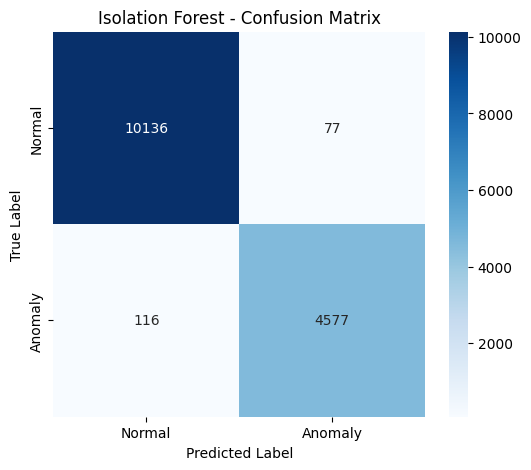

In [14]:
# =============================================================================
# ISOLATION FOREST PIPELINE (CLEAN + UNIQUE VARIABLES)
# =============================================================================
print("\n" + "="*60)
print("ISOLATION FOREST PIPELINE (CLEAN VERSION)")
print("="*60)

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import IsolationForest
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)

# ─────────────────────────────────────────────────────────────
# CONFIG
# ─────────────────────────────────────────────────────────────
if_contamination_rate = 0.05
if_target_fpr = 0.05

if_param_grid = {
    "n_estimators": [100, 200, 300],
    "max_samples": ["auto", 0.6, 0.8, 1.0],
    "max_features": [0.6, 0.8, 1.0]
}

print(f"Contamination fixed at: {if_contamination_rate}")

# ─────────────────────────────────────────────────────────────
# BEST TRACKING (Isolation Forest only)
# ─────────────────────────────────────────────────────────────
if_best_model = None
if_best_score = -1
if_best_params = None
if_best_threshold = None
if_best_val_scores = None

# ─────────────────────────────────────────────────────────────
# GRID SEARCH
# ─────────────────────────────────────────────────────────────
for if_n_est in if_param_grid["n_estimators"]:
    for if_max_samp in if_param_grid["max_samples"]:
        for if_max_feat in if_param_grid["max_features"]:

            if_model = IsolationForest(
                n_estimators=if_n_est,
                max_samples=if_max_samp,
                max_features=if_max_feat,
                contamination=if_contamination_rate,
                random_state=42,
                n_jobs=-1
            )

            if_model.fit(X_train_if_pca)

            # ── validation scores (higher = more anomalous)
            if_val_scores = -if_model.decision_function(X_val_if_pca)

            if_val_normal = if_val_scores[y_val.values == 0]
            if_val_attack = if_val_scores[y_val.values == 1]

            # ── threshold tuning
            if_best_t = None
            if_best_tpr = 0

            for p in np.linspace(90, 99.9, 150):
                t = np.percentile(if_val_normal, p)

                fpr = (if_val_normal >= t).mean()
                tpr = (if_val_attack >= t).mean()

                if fpr <= if_target_fpr and tpr > if_best_tpr:
                    if_best_tpr = tpr
                    if_best_t = t

            if if_best_t is None:
                if_best_t = np.percentile(if_val_normal, 95)

            # ── validation predictions
            if_y_val_pred = (if_val_scores >= if_best_t).astype(int)

            if_prec = precision_score(y_val, if_y_val_pred, zero_division=0)
            if_rec  = recall_score(y_val, if_y_val_pred, zero_division=0)
            if_f1   = f1_score(y_val, if_y_val_pred, zero_division=0)

            # score function (balance)
            if_score = if_f1 - abs(0.05 - (if_val_normal >= if_best_t).mean())

            print(f"n={if_n_est:<3} samp={str(if_max_samp):<5} feat={if_max_feat} | "
                  f"P={if_prec:.2f} R={if_rec:.2f} F1={if_f1:.2f} | score={if_score:.3f}")

            # ── save best model
            if if_score > if_best_score:
                if_best_score = if_score
                if_best_model = if_model
                if_best_params = {
                    "n_estimators": if_n_est,
                    "max_samples": if_max_samp,
                    "max_features": if_max_feat,
                    "contamination": if_contamination_rate
                }
                if_best_threshold = if_best_t
                if_best_val_scores = if_val_scores

# =============================================================================
# BEST MODEL SUMMARY
# =============================================================================
print("\n" + "="*50)
print(" BEST ISOLATION FOREST MODEL")
print("="*50)
print(if_best_params)
print(f"Best score : {if_best_score:.4f}")
print(f"Threshold  : {if_best_threshold:.4f}")

# =============================================================================
# EVALUATION
# =============================================================================
if_eval_scores = -if_best_model.decision_function(X_eval_if_pca)

if_y_pred = (if_eval_scores >= if_best_threshold).astype(int)

if_prec = precision_score(y_eval, if_y_pred, zero_division=0)
if_rec  = recall_score(y_eval, if_y_pred, zero_division=0)
if_f1   = f1_score(y_eval, if_y_pred, zero_division=0)
if_roc  = roc_auc_score(y_eval, if_eval_scores)

if_cm = confusion_matrix(y_eval, if_y_pred)

print("\n" + "="*40)
print(" FINAL RESULTS — ISOLATION FOREST")
print("="*40)

print(classification_report(y_eval, if_y_pred, digits=4))

print(f"Precision : {if_prec:.4f}")
print(f"Recall    : {if_rec:.4f}")
print(f"F1-score  : {if_f1:.4f}")
print(f"ROC-AUC   : {if_roc:.4f}")

print("\nConfusion Matrix:")
print(if_cm)

# =============================================================================
# HEATMAP
# =============================================================================
plt.figure(figsize=(6,5))
sns.heatmap(
    if_cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Normal', 'Anomaly'],
    yticklabels=['Normal', 'Anomaly']
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Isolation Forest - Confusion Matrix")
plt.show()


In [15]:
# import joblib

# print("\nSAVING ISOLATION FOREST ARTIFACTS...")

# joblib.dump(if_best_model, "isolation_forest.pkl")

# joblib.dump({
#     "threshold": if_best_threshold,
#     "params": if_best_params
# }, "if_metadata.pkl")

# print("✔ isolation_forest.pkl saved")
# print("✔ if_metadata.pkl saved")


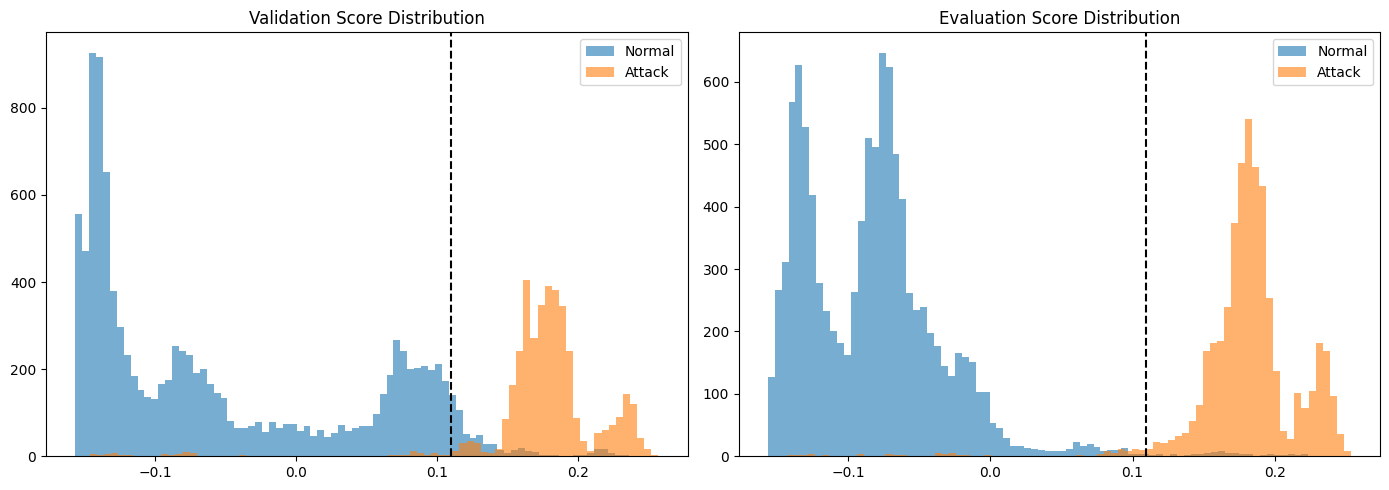

In [16]:
# =============================================================================
#  DISTRIBUTION PLOTS (VAL + EVAL)
# =============================================================================
val_normal = if_best_val_scores[y_val.values == 0]
val_attack = if_best_val_scores[y_val.values == 1]

eval_normal = if_eval_scores[y_eval.values == 0]
eval_attack = if_eval_scores[y_eval.values == 1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── VAL DISTRIBUTION ─────────────────────────────
axes[0].hist(val_normal, bins=80, alpha=0.6, label="Normal")
axes[0].hist(val_attack, bins=80, alpha=0.6, label="Attack")
axes[0].axvline(if_best_threshold, color="black", linestyle="--")
axes[0].set_title("Validation Score Distribution")
axes[0].legend()

# ── EVAL DISTRIBUTION ────────────────────────────
axes[1].hist(eval_normal, bins=80, alpha=0.6, label="Normal")
axes[1].hist(eval_attack, bins=80, alpha=0.6, label="Attack")
axes[1].axvline(if_best_threshold, color="black", linestyle="--")
axes[1].set_title("Evaluation Score Distribution")
axes[1].legend()

plt.tight_layout()
plt.show()

In [17]:
print('ff')

ff


# **OSVM**


ONE-CLASS SVM PIPELINE (CLEAN VERSION)
Starting OCSVM grid search...

nu=0.01 gamma=scale  | P=0.87 R=0.91 F1=0.89 ROC=0.977 | score=0.889
nu=0.01 gamma=0.01   | P=0.84 R=0.77 F1=0.80 ROC=0.964 | score=0.804
nu=0.01 gamma=0.05   | P=0.86 R=0.85 F1=0.85 ROC=0.969 | score=0.851
nu=0.01 gamma=0.1    | P=0.85 R=0.77 F1=0.81 ROC=0.959 | score=0.806
nu=0.03 gamma=scale  | P=0.87 R=0.94 F1=0.90 ROC=0.981 | score=0.904
nu=0.03 gamma=0.01   | P=0.87 R=0.94 F1=0.90 ROC=0.979 | score=0.904
nu=0.03 gamma=0.05   | P=0.87 R=0.94 F1=0.90 ROC=0.980 | score=0.904
nu=0.03 gamma=0.1    | P=0.86 R=0.85 F1=0.85 ROC=0.969 | score=0.851
nu=0.05 gamma=scale  | P=0.87 R=0.94 F1=0.90 ROC=0.982 | score=0.904
nu=0.05 gamma=0.01   | P=0.87 R=0.94 F1=0.90 ROC=0.978 | score=0.904
nu=0.05 gamma=0.05   | P=0.87 R=0.94 F1=0.90 ROC=0.981 | score=0.904
nu=0.05 gamma=0.1    | P=0.86 R=0.90 F1=0.88 ROC=0.972 | score=0.881
nu=0.1  gamma=scale  | P=0.87 R=0.94 F1=0.90 ROC=0.982 | score=0.904
nu=0.1  gamma=0.01   | P=0.87 R=

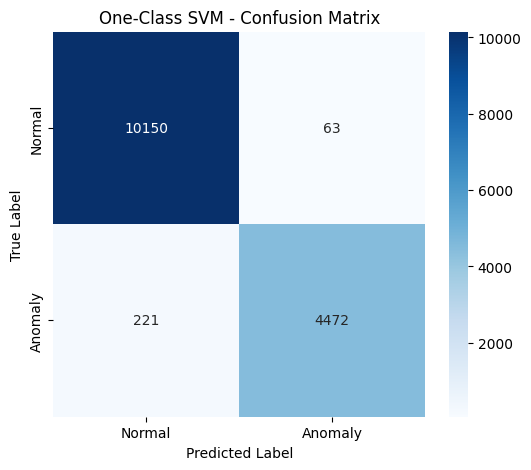

In [18]:
# =============================================================================
# ONE-CLASS SVM PIPELINE (CLEAN + UNIQUE VARIABLES)
# =============================================================================
print("\n" + "="*60)
print("ONE-CLASS SVM PIPELINE (CLEAN VERSION)")
print("="*60)

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.svm import OneClassSVM
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    confusion_matrix, classification_report
)

# ─────────────────────────────────────────────────────────────
# CONFIG
# ─────────────────────────────────────────────────────────────
osvm_target_fpr = 0.05

osvm_param_grid = {
    "nu": [0.01, 0.03, 0.05, 0.1],
    "gamma": ["scale", 0.01, 0.05, 0.1],
    # "kernel": ["linear", "rbf", "poly", "sigmoid"]
    "kernel": ["rbf"]
}

print("Starting OCSVM grid search...\n")

# ─────────────────────────────────────────────────────────────
# BEST TRACKING (OCSVM only)
# ─────────────────────────────────────────────────────────────
osvm_best_model = None
osvm_best_params = None
osvm_best_threshold = None
osvm_best_score = -1
osvm_best_val_scores = None

# ─────────────────────────────────────────────────────────────
# GRID SEARCH
# ─────────────────────────────────────────────────────────────
for osvm_nu in osvm_param_grid["nu"]:
    for osvm_gamma in osvm_param_grid["gamma"]:
        for osvm_kernel in osvm_param_grid["kernel"]:

            osvm_model = OneClassSVM(
                nu=osvm_nu,
                gamma=osvm_gamma,
                kernel=osvm_kernel
            )

            osvm_model.fit(X_train_if)

            # ── anomaly scores
            osvm_val_scores = -osvm_model.decision_function(X_val_if)

            osvm_val_normal = osvm_val_scores[y_val.values == 0]
            osvm_val_attack = osvm_val_scores[y_val.values == 1]

            # ── threshold tuning
            osvm_best_t = None
            osvm_best_tpr = 0

            for p in np.linspace(90, 99.9, 150):
                t = np.percentile(osvm_val_normal, p)

                fpr = (osvm_val_normal >= t).mean()
                tpr = (osvm_val_attack >= t).mean()

                if fpr <= osvm_target_fpr and tpr > osvm_best_tpr:
                    osvm_best_tpr = tpr
                    osvm_best_t = t

            if osvm_best_t is None:
                osvm_best_t = np.percentile(osvm_val_normal, 95)

            # ── validation predictions
            osvm_y_val_pred = (osvm_val_scores >= osvm_best_t).astype(int)

            osvm_prec = precision_score(y_val, osvm_y_val_pred, zero_division=0)
            osvm_rec  = recall_score(y_val, osvm_y_val_pred, zero_division=0)
            osvm_f1   = f1_score(y_val, osvm_y_val_pred, zero_division=0)
            osvm_roc  = roc_auc_score(y_val, osvm_val_scores)

            # balanced score
            osvm_score = osvm_f1 - abs(0.05 - (osvm_val_normal >= osvm_best_t).mean())

            print(
                f"nu={osvm_nu:<4} gamma={str(osvm_gamma):<6} | "
                f"P={osvm_prec:.2f} R={osvm_rec:.2f} F1={osvm_f1:.2f} ROC={osvm_roc:.3f} | "
                f"score={osvm_score:.3f}"
            )

            # ── save best model
            if osvm_score > osvm_best_score:
                osvm_best_score = osvm_score
                osvm_best_model = osvm_model
                osvm_best_params = {
                    "nu": osvm_nu,
                    "gamma": osvm_gamma,
                    "kernel": osvm_kernel
                }
                osvm_best_threshold = osvm_best_t
                osvm_best_val_scores = osvm_val_scores

# =============================================================================
# BEST MODEL SUMMARY
# =============================================================================
print("\n" + "="*50)
print(" BEST OCSVM MODEL")
print("="*50)
print(osvm_best_params)
print(f"Best score : {osvm_best_score:.4f}")
print(f"Threshold  : {osvm_best_threshold:.4f}")

# =============================================================================
# EVALUATION
# =============================================================================
osvm_eval_scores = -osvm_best_model.decision_function(X_eval_if)

osvm_y_pred = (osvm_eval_scores >= osvm_best_threshold).astype(int)

osvm_prec = precision_score(y_eval, osvm_y_pred, zero_division=0)
osvm_rec  = recall_score(y_eval, osvm_y_pred, zero_division=0)
osvm_f1   = f1_score(y_eval, osvm_y_pred, zero_division=0)
osvm_roc  = roc_auc_score(y_eval, osvm_eval_scores)
osvm_ap   = average_precision_score(y_eval, osvm_eval_scores)

osvm_cm = confusion_matrix(y_eval, osvm_y_pred)

# =============================================================================
# RESULTS
# =============================================================================
print("\n" + "="*40)
print(" FINAL RESULTS — OCSVM")
print("="*40)

print(classification_report(y_eval, osvm_y_pred, digits=4))

print(f"Precision : {osvm_prec:.4f}")
print(f"Recall    : {osvm_rec:.4f}")
print(f"F1-score  : {osvm_f1:.4f}")
print(f"ROC-AUC   : {osvm_roc:.4f}")
print(f"Avg Prec  : {osvm_ap:.4f}")

print("\nConfusion Matrix:")
print(osvm_cm)

# =============================================================================
# HEATMAP
# =============================================================================
plt.figure(figsize=(6,5))
sns.heatmap(
    osvm_cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Normal', 'Anomaly'],
    yticklabels=['Normal', 'Anomaly']
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("One-Class SVM - Confusion Matrix")
plt.show()


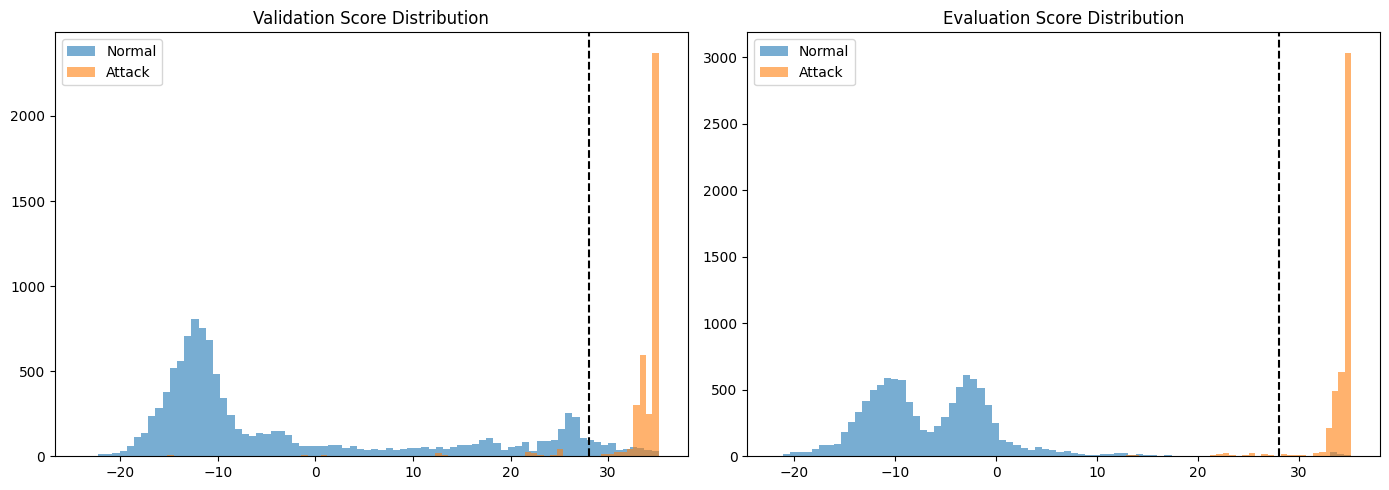

In [19]:
# =============================================================================
#  DISTRIBUTION PLOTS (VAL + EVAL)
# =============================================================================
val_normal = osvm_best_val_scores[y_val.values == 0]
val_attack = osvm_best_val_scores[y_val.values == 1]

eval_normal = osvm_eval_scores[y_eval.values == 0]
eval_attack = osvm_eval_scores[y_eval.values == 1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── VAL DISTRIBUTION ─────────────────────────────
axes[0].hist(val_normal, bins=80, alpha=0.6, label="Normal")
axes[0].hist(val_attack, bins=80, alpha=0.6, label="Attack")
# axes[0].axvline(30, color="black", linestyle="--")
axes[0].axvline(osvm_best_threshold, color="black", linestyle="--")
axes[0].set_title("Validation Score Distribution")
axes[0].legend()

# ── EVAL DISTRIBUTION ────────────────────────────
axes[1].hist(eval_normal, bins=80, alpha=0.6, label="Normal")
axes[1].hist(eval_attack, bins=80, alpha=0.6, label="Attack")
# axes[1].axvline(30, color="black", linestyle="--")
axes[1].axvline(osvm_best_threshold, color="black", linestyle="--")
axes[1].set_title("Evaluation Score Distribution")
axes[1].legend()

plt.tight_layout()
plt.show()

In [20]:
# import joblib

# print("\nSAVING OCSVM ARTIFACTS...")

# joblib.dump(osvm_best_model, "ocsvm.pkl")

# joblib.dump({
#     "threshold": osvm_best_threshold,
#     "params": osvm_best_params
# }, "ocsvm_metadata.pkl")

# print("✔ ocsvm.pkl saved")
# print("✔ ocsvm_metadata.pkl saved")


# **Autoencoder**


IMPROVED AUTOENCODER TRAINING
Epoch 1/150


2026-06-22 14:44:07.840599: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.6813 - val_loss: 0.4271 - learning_rate: 0.0010
Epoch 2/150
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3706 - val_loss: 0.3811 - learning_rate: 0.0010
Epoch 3/150
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3290 - val_loss: 0.3752 - learning_rate: 0.0010
Epoch 4/150
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3050 - val_loss: 0.3437 - learning_rate: 0.0010
Epoch 5/150
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2898 - val_loss: 0.3317 - learning_rate: 0.0010
Epoch 6/150
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2773 - val_loss: 0.3195 - learning_rate: 0.0010
Epoch 7/150
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2680 - val_loss: 0.3138 - learning_rate: 0.0010
Epoch 8/150
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2642 - val_loss: 0.3133 - learning_rate: 0.0010
Epoch 9/150
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2599 - val_loss: 0.3213 - learning_rate: 0.0010
Epoch 10/150


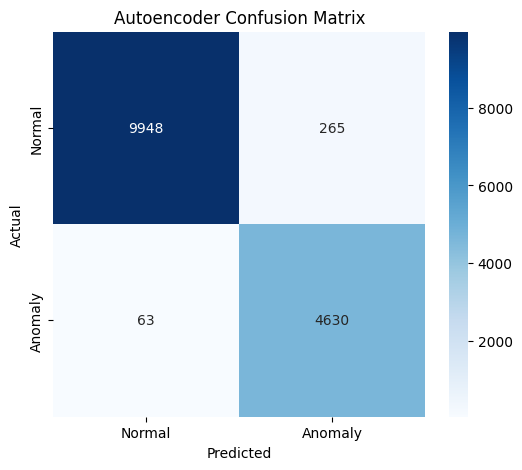

In [21]:
# =============================================================================
# IMPROVED AUTOENCODER (FINAL CORRECT VERSION — UNIQUE VARIABLES)
# =============================================================================
print("\n" + "="*60)
print("IMPROVED AUTOENCODER TRAINING")
print("="*60)

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow import keras
from tensorflow.keras import layers, callbacks
from sklearn.metrics import (
    f1_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score
)

# ─────────────────────────────────────────────────────────────
# NOISE AUGMENTATION (ROBUSTNESS)
# ─────────────────────────────────────────────────────────────
noise_factor = 0.01
X_train_noisy_ae = X_train_ae + np.random.normal(0, noise_factor, X_train_ae.shape)

# ─────────────────────────────────────────────────────────────
# MODEL ARCHITECTURE
# ─────────────────────────────────────────────────────────────
def build_autoencoder(input_dim: int):

    enc1 = max(64, input_dim * 2)
    enc2 = max(32, input_dim)
    bottleneck = max(8, input_dim // 3)

    inp = keras.Input(shape=(input_dim,))

    x = layers.Dense(enc1, activation='relu')(inp)
    x = layers.Dropout(0.2)(x)
    x = layers.BatchNormalization()(x)

    x = layers.Dense(enc2, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    x = layers.BatchNormalization()(x)

    x = layers.Dense(bottleneck, activation='relu')(x)

    x = layers.Dense(enc2, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    x = layers.BatchNormalization()(x)

    x = layers.Dense(enc1, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    x = layers.BatchNormalization()(x)

    out = layers.Dense(input_dim, activation='linear')(x)

    model_ae = keras.Model(inp, out)

    model_ae.compile(
        optimizer=keras.optimizers.Adam(1e-3),
        loss='mae'
    )

    return model_ae


# ─────────────────────────────────────────────────────────────
# TRAINING
# ─────────────────────────────────────────────────────────────
model_ae = build_autoencoder(X_train_ae.shape[1])

history_ae = model_ae.fit(
    X_train_noisy_ae, X_train_ae,
    epochs=150,
    batch_size=256,
    validation_data=(X_val_ae_normal, X_val_ae_normal),
    callbacks=[
        callbacks.EarlyStopping(
            monitor='val_loss',
            patience=10,
            restore_best_weights=True,
            verbose=1
        ),
        callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=5,
            min_lr=1e-6,
            verbose=1
        )
    ],
    verbose=1
)

# ─────────────────────────────────────────────────────────────
# RECONSTRUCTION ERROR
# ─────────────────────────────────────────────────────────────
def recon_error_ae(model, X):
    X_pred = model.predict(X, batch_size=256, verbose=0)
    return np.mean(np.abs(X - X_pred), axis=1)

train_errors_ae = recon_error_ae(model_ae, X_train_ae)
val_errors_ae   = recon_error_ae(model_ae, X_val_ae)
eval_errors_ae  = recon_error_ae(model_ae, X_eval_ae)

val_normal_errors_ae  = val_errors_ae[y_val.values == 0]
val_attack_errors_ae  = val_errors_ae[y_val.values == 1]
eval_normal_errors_ae = eval_errors_ae[y_eval.values == 0]
eval_attack_errors_ae = eval_errors_ae[y_eval.values == 1]

# ─────────────────────────────────────────────────────────────
# THRESHOLD
# ─────────────────────────────────────────────────────────────
combined_normals_ae = np.concatenate([train_errors_ae, val_normal_errors_ae])

target_fpr_ae = 0.07

best_thresh_ae = None
best_recall_ae = -1
best_f1_ae = -1

for pct in np.linspace(90, 99.5, 400):

    thresh = np.percentile(combined_normals_ae, pct)

    y_val_pred_ae = (val_errors_ae >= thresh).astype(int)

    fpr = (val_normal_errors_ae >= thresh).mean()
    rec = recall_score(y_val, y_val_pred_ae, zero_division=0)
    prec = precision_score(y_val, y_val_pred_ae, zero_division=0)
    f1 = f1_score(y_val, y_val_pred_ae, zero_division=0)

    if fpr <= target_fpr_ae:
        if rec > best_recall_ae or (rec == best_recall_ae and f1 > best_f1_ae):
            best_recall_ae = rec
            best_f1_ae = f1
            best_thresh_ae = thresh

if best_thresh_ae is None:
    best_thresh_ae = np.percentile(combined_normals_ae, 95)

print(f"\nChosen threshold: {best_thresh_ae:.6f}")
print(f"Best VAL Recall : {best_recall_ae:.4f}")
print(f"Best VAL F1     : {best_f1_ae:.4f}")

# ─────────────────────────────────────────────────────────────
# FINAL EVALUATION
# ─────────────────────────────────────────────────────────────
y_pred_ae = (eval_errors_ae >= best_thresh_ae).astype(int)

prec_ae = precision_score(y_eval, y_pred_ae, zero_division=0)
rec_ae  = recall_score(y_eval, y_pred_ae, zero_division=0)
f1_ae   = f1_score(y_eval, y_pred_ae, zero_division=0)

roc_ae  = roc_auc_score(y_eval, eval_errors_ae)
ap_ae   = average_precision_score(y_eval, eval_errors_ae)

cm_ae = confusion_matrix(y_eval, y_pred_ae)

# ─────────────────────────────────────────────────────────────
# RESULTS
# ─────────────────────────────────────────────────────────────
print("\n========================================")
print(" FINAL RESULTS — IMPROVED AE")
print("========================================")

print(f"Precision : {prec_ae:.4f}")
print(f"Recall    : {rec_ae:.4f}")
print(f"F1-score  : {f1_ae:.4f}")

print(f"\nROC-AUC   : {roc_ae:.4f}")
print(f"Avg Prec  : {ap_ae:.4f}")

print("\nConfusion Matrix:")
print(cm_ae)

print("\nDetailed Report:")
print(classification_report(y_eval, y_pred_ae, digits=4))

# ─────────────────────────────────────────────────────────────
# HEATMAP
# ─────────────────────────────────────────────────────────────
plt.figure(figsize=(6,5))
sns.heatmap(cm_ae, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Anomaly'],
            yticklabels=['Normal', 'Anomaly'])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Autoencoder Confusion Matrix")
plt.show()


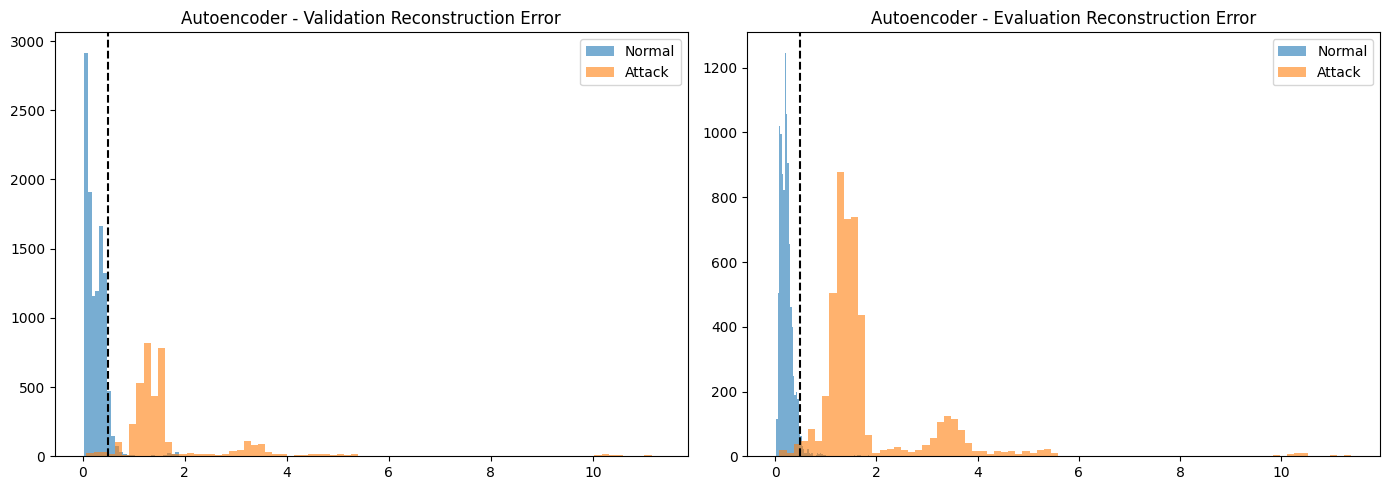

In [22]:
# =============================================================================
# AUTOENCODER — DISTRIBUTION PLOTS (VAL + EVAL)
# =============================================================================

val_normal_ae = val_errors_ae[y_val.values == 0]
val_attack_ae = val_errors_ae[y_val.values == 1]

eval_normal_ae = eval_errors_ae[y_eval.values == 0]
eval_attack_ae = eval_errors_ae[y_eval.values == 1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── VAL DISTRIBUTION ─────────────────────────────
axes[0].hist(val_normal_ae, bins=80, alpha=0.6, label="Normal")
axes[0].hist(val_attack_ae, bins=80, alpha=0.6, label="Attack")
axes[0].axvline(best_thresh_ae, color="black", linestyle="--")
axes[0].set_title("Autoencoder - Validation Reconstruction Error")
axes[0].legend()

# ── EVAL DISTRIBUTION ────────────────────────────
axes[1].hist(eval_normal_ae, bins=80, alpha=0.6, label="Normal")
axes[1].hist(eval_attack_ae, bins=80, alpha=0.6, label="Attack")
axes[1].axvline(best_thresh_ae, color="black", linestyle="--")
axes[1].set_title("Autoencoder - Evaluation Reconstruction Error")
axes[1].legend()

plt.tight_layout()
plt.show()

In [23]:
# import joblib
# import os

# os.makedirs("artifacts", exist_ok=True)

# # -----------------------------
# # 1. Save Autoencoder model
# # -----------------------------
# model_ae.save("artifacts/autoencoder_model.keras")

# # -----------------------------
# # 2. Save threshold + metadata
# # -----------------------------
# ae_artifacts = {
#     "threshold": best_thresh_ae,
#     "noise_factor": noise_factor,
#     "input_dim": X_train_ae.shape[1]
# }

# joblib.dump(ae_artifacts, "artifacts/autoencoder_artifacts.pkl")

# print("✔ Autoencoder saved successfully")


In [24]:
# Precision : 0.9497
# Recall    : 0.9821
# F1-score  : 0.9656

# ROC-AUC   : 0.9931
# Avg Prec  : 0.9838

# Confusion Matrix:
# [[9969  244]
#  [  84 4609]]

In [25]:
# =============================================================================
# ENSEMBLE USING VALIDATION THRESHOLD
# =============================================================================

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

# ============================================================
# STEP 1 — NORMALIZE USING VAL + EVAL
# ============================================================

scaler_if = MinMaxScaler()
scaler_ocsvm = MinMaxScaler()
scaler_ae = MinMaxScaler()

# Fit on validation scores
scaler_if.fit(if_best_val_scores.reshape(-1,1))
scaler_ocsvm.fit(osvm_best_val_scores.reshape(-1,1))
scaler_ae.fit(val_errors_ae.reshape(-1,1))

# Transform validation
val_if_norm = scaler_if.transform(
    if_best_val_scores.reshape(-1,1)
).flatten()

val_ocsvm_norm = scaler_ocsvm.transform(
    osvm_best_val_scores.reshape(-1,1)
).flatten()

val_ae_norm = scaler_ae.transform(
    val_errors_ae.reshape(-1,1)
).flatten()

# Transform evaluation
eval_if_norm = scaler_if.transform(
    if_eval_scores.reshape(-1,1)
).flatten()

eval_ocsvm_norm = scaler_ocsvm.transform(
    osvm_eval_scores.reshape(-1,1)
).flatten()

eval_ae_norm = scaler_ae.transform(
    eval_errors_ae.reshape(-1,1)
).flatten()

# ============================================================
# STEP 2 — ENSEMBLE SCORES
# ============================================================

w_if = 0.40
w_ocsvm = 0.25
w_ae = 0.35

val_ensemble_scores = (
    w_if * val_if_norm +
    w_ocsvm * val_ocsvm_norm +
    w_ae * val_ae_norm
)

eval_ensemble_scores = (
    w_if * eval_if_norm +
    w_ocsvm * eval_ocsvm_norm +
    w_ae * eval_ae_norm
)

# ============================================================
# STEP 3 — THRESHOLD SEARCH ON VALIDATION ONLY
# ============================================================

best_thresh = None
best_recall = -1
best_f1 = -1

target_fpr = 0.02

val_normal_scores = val_ensemble_scores[y_val.values == 0]

for pct in np.linspace(90, 99.5, 100):

    thresh = np.percentile(val_normal_scores, pct)

    y_val_pred = (
        val_ensemble_scores >= thresh
    ).astype(int)

    fpr = (val_normal_scores >= thresh).mean()

    prec = precision_score(
        y_val,
        y_val_pred,
        zero_division=0
    )

    rec = recall_score(
        y_val,
        y_val_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_val,
        y_val_pred,
        zero_division=0
    )

    if fpr <= target_fpr:

        if rec >= prec:

            if rec > best_recall or (
                rec == best_recall and f1 > best_f1
            ):
                best_recall = rec
                best_f1 = f1
                best_thresh = thresh

if best_thresh is None:
    best_thresh = np.percentile(
        val_normal_scores,
        95
    )

print("\nChosen Threshold:", best_thresh)

# ============================================================
# STEP 4 — APPLY TO EVALUATION SET
# ============================================================

y_pred_ensemble = (
    eval_ensemble_scores >= best_thresh
).astype(int)

# ============================================================
# STEP 5 — FINAL METRICS
# ============================================================

prec = precision_score(y_eval, y_pred_ensemble)
rec = recall_score(y_eval, y_pred_ensemble)
f1 = f1_score(y_eval, y_pred_ensemble)

roc = roc_auc_score(
    y_eval,
    eval_ensemble_scores
)

ap = average_precision_score(
    y_eval,
    eval_ensemble_scores
)

cm = confusion_matrix(
    y_eval,
    y_pred_ensemble
)

print("\n==================================================")
print("FINAL RESULTS — ENSEMBLE")
print("==================================================")

print(f"Precision : {prec:.4f}")
print(f"Recall    : {rec:.4f}")
print(f"F1-score  : {f1:.4f}")
print(f"ROC-AUC   : {roc:.4f}")
print(f"Avg Prec  : {ap:.4f}")

print("\nConfusion Matrix:")
print(cm)

print(
    classification_report(
        y_eval,
        y_pred_ensemble,
        digits=4
    )
)


Chosen Threshold: 0.4887487989541728

FINAL RESULTS — ENSEMBLE
Precision : 0.9842
Recall    : 0.9668
F1-score  : 0.9754
ROC-AUC   : 0.9947
Avg Prec  : 0.9923

Confusion Matrix:
[[10140    73]
 [  156  4537]]
              precision    recall  f1-score   support

           0     0.9848    0.9929    0.9888     10213
           1     0.9842    0.9668    0.9754      4693

    accuracy                         0.9846     14906
   macro avg     0.9845    0.9798    0.9821     14906
weighted avg     0.9846    0.9846    0.9846     14906




 HARD VOTING ENSEMBLE
Precision : 0.9807
Recall    : 0.9753
F1-score  : 0.9780

Confusion Matrix:
[[10123    90]
 [  116  4577]]

Detailed Report:
              precision    recall  f1-score   support

           0     0.9887    0.9912    0.9899     10213
           1     0.9807    0.9753    0.9780      4693

    accuracy                         0.9862     14906
   macro avg     0.9847    0.9832    0.9840     14906
weighted avg     0.9862    0.9862    0.9862     14906



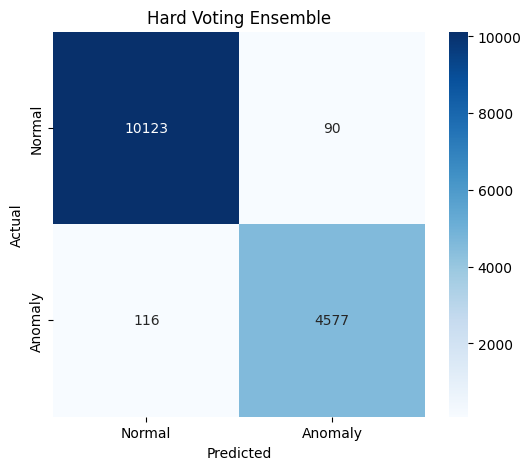

In [26]:
# =============================================================================
# HARD VOTING ENSEMBLE
# =============================================================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# ------------------------------------------------------------------
# Make sure lengths match
# ------------------------------------------------------------------

min_len = min(
    len(if_y_pred),
    len(osvm_y_pred),
    len(y_pred_ae),
    len(y_eval)
)

if_pred = np.array(if_y_pred[:min_len])
ocsvm_pred = np.array(osvm_y_pred[:min_len])
ae_pred = np.array(y_pred_ae[:min_len])

y_true = np.array(y_eval[:min_len])

# ------------------------------------------------------------------
# HARD VOTING (2 out of 3)
# ------------------------------------------------------------------

votes = (
    if_pred +
    ocsvm_pred +
    ae_pred
)

y_pred_hard = (votes >= 2).astype(int)

# ------------------------------------------------------------------
# METRICS
# ------------------------------------------------------------------

prec = precision_score(y_true, y_pred_hard)
rec = recall_score(y_true, y_pred_hard)
f1 = f1_score(y_true, y_pred_hard)

cm = confusion_matrix(y_true, y_pred_hard)

print("\n" + "="*50)
print(" HARD VOTING ENSEMBLE")
print("="*50)

print(f"Precision : {prec:.4f}")
print(f"Recall    : {rec:.4f}")
print(f"F1-score  : {f1:.4f}")

print("\nConfusion Matrix:")
print(cm)

print("\nDetailed Report:")
print(
    classification_report(
        y_true,
        y_pred_hard,
        digits=4
    )
)

# ------------------------------------------------------------------
# HEATMAP
# ------------------------------------------------------------------

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal", "Anomaly"],
    yticklabels=["Normal", "Anomaly"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Hard Voting Ensemble")

plt.show()

In [27]:
# # =============================================================================
# # DISTRIBUTION PLOTS — HYBRID ENSEMBLE
# # =============================================================================

# # Split validation and evaluation scores
# val_scores_ens = ensemble_scores[y_val.values == 0]  # normal (val)
# val_attack_ens = ensemble_scores[y_val.values == 1]   # attack (val)

# eval_scores_ens = ensemble_scores[y_eval.values == 0] # normal (eval)
# eval_attack_ens = ensemble_scores[y_eval.values == 1] # attack (eval)

# # Create plots
# fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# # ── VALIDATION DISTRIBUTION ─────────────────────────────
# axes[0].hist(val_scores_ens, bins=80, alpha=0.6, label="Normal", color="blue")
# axes[0].hist(val_attack_ens, bins=80, alpha=0.6, label="Attack", color="red")
# axes[0].axvline(best_thresh_ensemble, color="black", linestyle="--")
# axes[0].set_title("Validation Score Distribution (Ensemble)")
# axes[0].legend()

# # ── EVALUATION DISTRIBUTION ─────────────────────────────
# axes[1].hist(eval_scores_ens, bins=80, alpha=0.6, label="Normal", color="blue")
# axes[1].hist(eval_attack_ens, bins=80, alpha=0.6, label="Attack", color="red")
# axes[1].axvline(best_thresh_ensemble, color="black", linestyle="--")
# axes[1].set_title("Evaluation Score Distribution (Ensemble)")
# axes[1].legend()

# plt.tight_layout()
# plt.show()

NameError: name 'ensemble_scores' is not defined

In [ ]:
print(len(if_eval_scores))
print(len(osvm_eval_scores))
print(len(eval_errors_ae))
print(len(y_eval))


ISOLATION FOREST PIPELINE (NO INVERSION)
Contamination fixed at: 0.05
n=100 samp=auto  feat=0.6 | P=0.862 R=0.893 F1=0.877 | score=0.877
n=100 samp=auto  feat=0.8 | P=0.867 R=0.931 F1=0.898 | score=0.898
n=100 samp=auto  feat=1.0 | P=0.872 R=0.971 F1=0.919 | score=0.919
n=100 samp=0.6   feat=0.6 | P=0.868 R=0.944 F1=0.905 | score=0.905
n=100 samp=0.6   feat=0.8 | P=0.823 R=0.663 F1=0.734 | score=0.734
n=100 samp=0.6   feat=1.0 | P=0.819 R=0.645 F1=0.721 | score=0.721
n=100 samp=0.8   feat=0.6 | P=0.851 R=0.813 F1=0.831 | score=0.831
n=100 samp=0.8   feat=0.8 | P=0.868 R=0.942 F1=0.904 | score=0.904
n=100 samp=0.8   feat=1.0 | P=0.844 R=0.774 F1=0.808 | score=0.807
n=100 samp=1.0   feat=0.6 | P=0.868 R=0.940 F1=0.903 | score=0.903
n=100 samp=1.0   feat=0.8 | P=0.818 R=0.643 F1=0.721 | score=0.720
n=100 samp=1.0   feat=1.0 | P=0.869 R=0.948 F1=0.907 | score=0.906
n=200 samp=auto  feat=0.6 | P=0.851 R=0.813 F1=0.831 | score=0.831
n=200 samp=auto  feat=0.8 | P=0.863 R=0.899 F1=0.880 | sco

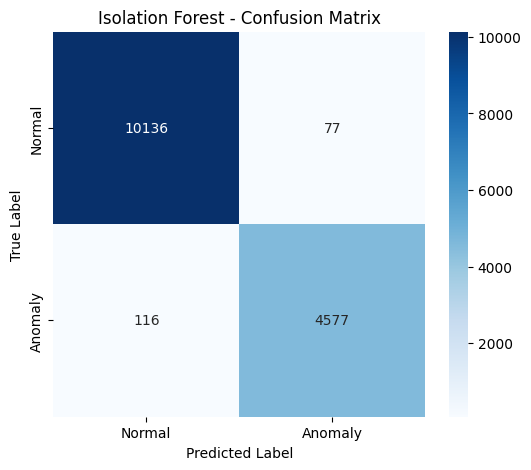

In [28]:
# =============================================================================
# ISOLATION FOREST PIPELINE (NO INVERSION VERSION)
# =============================================================================
print("\n" + "="*60)
print("ISOLATION FOREST PIPELINE (NO INVERSION)")
print("="*60)

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import IsolationForest
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# ─────────────────────────────────────────────────────────────
# CONFIG
# ─────────────────────────────────────────────────────────────
if_contamination_rate = 0.05
if_target_fpr = 0.05

if_param_grid = {
    "n_estimators": [100, 200, 300],
    "max_samples": ["auto", 0.6, 0.8, 1.0],
    "max_features": [0.6, 0.8, 1.0]
}

print(f"Contamination fixed at: {if_contamination_rate}")

# ─────────────────────────────────────────────────────────────
# BEST TRACKING
# ─────────────────────────────────────────────────────────────
if_best_model = None
if_best_score = -1
if_best_params = None
if_best_threshold = None
if_best_val_scores = None

# ─────────────────────────────────────────────────────────────
# GRID SEARCH
# ─────────────────────────────────────────────────────────────
for if_n_est in if_param_grid["n_estimators"]:
    for if_max_samp in if_param_grid["max_samples"]:
        for if_max_feat in if_param_grid["max_features"]:

            if_model = IsolationForest(
                n_estimators=if_n_est,
                max_samples=if_max_samp,
                max_features=if_max_feat,
                contamination=if_contamination_rate,
                random_state=42,
                n_jobs=-1
            )

            if_model.fit(X_train_if_pca)

            # ==========================================================
            # NO INVERSION
            # Higher score = normal
            # Lower score = anomaly
            # ==========================================================
            if_val_scores = if_model.decision_function(X_val_if_pca)

            if_val_normal = if_val_scores[y_val.values == 0]
            if_val_attack = if_val_scores[y_val.values == 1]

            # ==========================================================
            # THRESHOLD SEARCH
            # ==========================================================
            if_best_t = None
            if_best_tpr = 0

            for p in np.linspace(90, 95, 150):  #0.1, 10, 150

                # lower percentile because anomalies have LOW scores
                t = np.percentile(if_val_normal, p)

                fpr = (if_val_normal <= t).mean()
                tpr = (if_val_attack <= t).mean()

                if fpr <= if_target_fpr and tpr > if_best_tpr:
                    if_best_tpr = tpr
                    if_best_t = t

            if if_best_t is None:
                if_best_t = np.percentile(if_val_normal, 5)

            # ==========================================================
            # VALIDATION PREDICTIONS
            # anomaly if score <= threshold
            # ==========================================================
            if_y_val_pred = (if_val_scores <= if_best_t).astype(int)

            if_prec = precision_score(
                y_val,
                if_y_val_pred,
                zero_division=0
            )

            if_rec = recall_score(
                y_val,
                if_y_val_pred,
                zero_division=0
            )

            if_f1 = f1_score(
                y_val,
                if_y_val_pred,
                zero_division=0
            )

            current_fpr = (if_val_normal <= if_best_t).mean()

            if_score = if_f1 - abs(
                if_target_fpr - current_fpr
            )

            print(
                f"n={if_n_est:<3} "
                f"samp={str(if_max_samp):<5} "
                f"feat={if_max_feat} | "
                f"P={if_prec:.3f} "
                f"R={if_rec:.3f} "
                f"F1={if_f1:.3f} | "
                f"score={if_score:.3f}"
            )

            # ==========================================================
            # SAVE BEST
            # ==========================================================
            if if_score > if_best_score:

                if_best_score = if_score
                if_best_model = if_model

                if_best_params = {
                    "n_estimators": if_n_est,
                    "max_samples": if_max_samp,
                    "max_features": if_max_feat,
                    "contamination": if_contamination_rate
                }

                if_best_threshold = if_best_t
                if_best_val_scores = if_val_scores

# =============================================================================
# BEST MODEL SUMMARY
# =============================================================================
print("\n" + "="*50)
print(" BEST ISOLATION FOREST MODEL")
print("="*50)

print(if_best_params)
print(f"Best score : {if_best_score:.4f}")
print(f"Threshold  : {if_best_threshold:.6f}")

# =============================================================================
# EVALUATION
# =============================================================================

# NO INVERSION
if_eval_scores = if_best_model.decision_function(
    X_eval_if_pca
)

# anomaly if score <= threshold
if_y_pred = (
    if_eval_scores <= if_best_threshold
).astype(int)

if_prec = precision_score(
    y_eval,
    if_y_pred,
    zero_division=0
)

if_rec = recall_score(
    y_eval,
    if_y_pred,
    zero_division=0
)

if_f1 = f1_score(
    y_eval,
    if_y_pred,
    zero_division=0
)

# invert only for ROC-AUC because larger score should
# correspond to positive class (attack)
if_roc = roc_auc_score(
    y_eval,
    -if_eval_scores
)

if_cm = confusion_matrix(
    y_eval,
    if_y_pred
)

print("\n" + "="*40)
print(" FINAL RESULTS — ISOLATION FOREST")
print("="*40)

print(
    classification_report(
        y_eval,
        if_y_pred,
        digits=4
    )
)

print(f"Precision : {if_prec:.4f}")
print(f"Recall    : {if_rec:.4f}")
print(f"F1-score  : {if_f1:.4f}")
print(f"ROC-AUC   : {if_roc:.4f}")

print("\nConfusion Matrix:")
print(if_cm)

# =============================================================================
# HEATMAP
# =============================================================================
plt.figure(figsize=(6,5))

sns.heatmap(
    if_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal", "Anomaly"],
    yticklabels=["Normal", "Anomaly"]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Isolation Forest - Confusion Matrix")

plt.show()

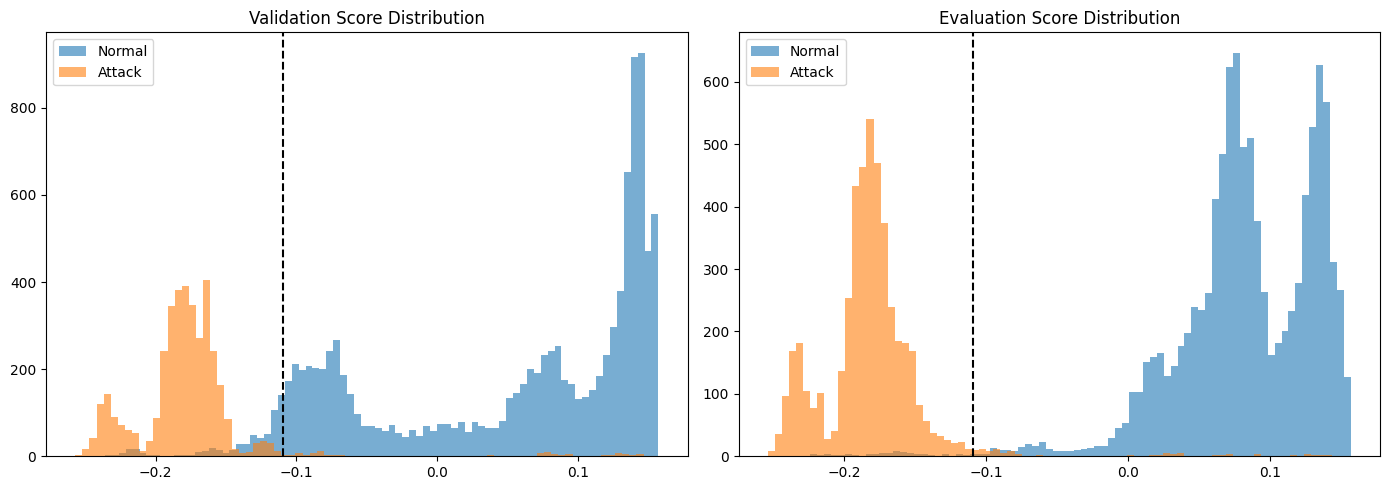

In [29]:
# =============================================================================
#  DISTRIBUTION PLOTS (VAL + EVAL)
# =============================================================================
val_normal = if_best_val_scores[y_val.values == 0]
val_attack = if_best_val_scores[y_val.values == 1]

eval_normal = if_eval_scores[y_eval.values == 0]
eval_attack = if_eval_scores[y_eval.values == 1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── VAL DISTRIBUTION ─────────────────────────────
axes[0].hist(val_normal, bins=80, alpha=0.6, label="Normal")
axes[0].hist(val_attack, bins=80, alpha=0.6, label="Attack")
axes[0].axvline(if_best_threshold, color="black", linestyle="--")
axes[0].set_title("Validation Score Distribution")
axes[0].legend()

# ── EVAL DISTRIBUTION ────────────────────────────
axes[1].hist(eval_normal, bins=80, alpha=0.6, label="Normal")
axes[1].hist(eval_attack, bins=80, alpha=0.6, label="Attack")
axes[1].axvline(if_best_threshold, color="black", linestyle="--")
axes[1].set_title("Evaluation Score Distribution")
axes[1].legend()

plt.tight_layout()
plt.show()


ONE-CLASS SVM PIPELINE (NO INVERSION)
Starting OCSVM grid search...

nu=0.01 gamma=scale  | P=0.865 R=0.915 F1=0.889 ROC=0.977 | score=0.889
nu=0.01 gamma=0.01   | P=0.844 R=0.772 F1=0.806 ROC=0.964 | score=0.806
nu=0.01 gamma=0.05   | P=0.856 R=0.845 F1=0.850 ROC=0.969 | score=0.850
nu=0.01 gamma=0.1    | P=0.844 R=0.772 F1=0.806 ROC=0.959 | score=0.806
nu=0.03 gamma=scale  | P=0.868 R=0.942 F1=0.904 ROC=0.981 | score=0.904
nu=0.03 gamma=0.01   | P=0.868 R=0.942 F1=0.904 ROC=0.979 | score=0.904
nu=0.03 gamma=0.05   | P=0.868 R=0.942 F1=0.904 ROC=0.980 | score=0.904
nu=0.03 gamma=0.1    | P=0.856 R=0.847 F1=0.852 ROC=0.969 | score=0.852
nu=0.05 gamma=scale  | P=0.868 R=0.942 F1=0.904 ROC=0.982 | score=0.904
nu=0.05 gamma=0.01   | P=0.868 R=0.942 F1=0.904 ROC=0.978 | score=0.904
nu=0.05 gamma=0.05   | P=0.868 R=0.942 F1=0.904 ROC=0.981 | score=0.904
nu=0.05 gamma=0.1    | P=0.863 R=0.900 F1=0.881 ROC=0.972 | score=0.881
nu=0.1  gamma=scale  | P=0.868 R=0.942 F1=0.904 ROC=0.982 | score=

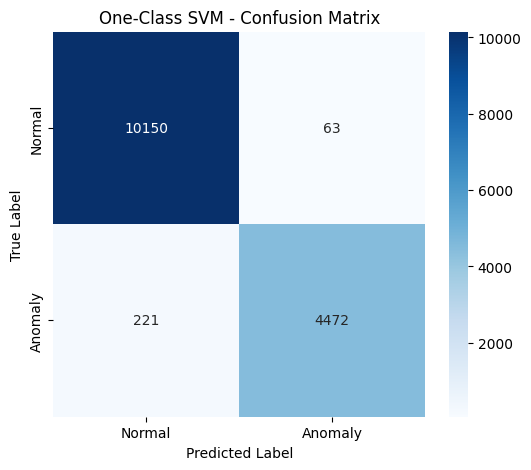

In [30]:
# =============================================================================
# ONE-CLASS SVM PIPELINE (NO INVERSION VERSION)
# =============================================================================
print("\n" + "="*60)
print("ONE-CLASS SVM PIPELINE (NO INVERSION)")
print("="*60)

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.svm import OneClassSVM
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

# ─────────────────────────────────────────────────────────────
# CONFIG
# ─────────────────────────────────────────────────────────────
osvm_target_fpr = 0.05

osvm_param_grid = {
    "nu": [0.01, 0.03, 0.05, 0.1],
    "gamma": ["scale", 0.01, 0.05, 0.1],
    "kernel": ["rbf"]
}

print("Starting OCSVM grid search...\n")

# ─────────────────────────────────────────────────────────────
# BEST TRACKING
# ─────────────────────────────────────────────────────────────
osvm_best_model = None
osvm_best_params = None
osvm_best_threshold = None
osvm_best_score = -1
osvm_best_val_scores = None

# ─────────────────────────────────────────────────────────────
# GRID SEARCH
# ─────────────────────────────────────────────────────────────
for osvm_nu in osvm_param_grid["nu"]:

    for osvm_gamma in osvm_param_grid["gamma"]:

        for osvm_kernel in osvm_param_grid["kernel"]:

            osvm_model = OneClassSVM(
                nu=osvm_nu,
                gamma=osvm_gamma,
                kernel=osvm_kernel
            )

            osvm_model.fit(X_train_if)

            # =====================================================
            # NO INVERSION
            # Higher = normal
            # Lower = anomaly
            # =====================================================
            osvm_val_scores = osvm_model.decision_function(
                X_val_if
            )

            osvm_val_normal = osvm_val_scores[
                y_val.values == 0
            ]

            osvm_val_attack = osvm_val_scores[
                y_val.values == 1
            ]

            # =====================================================
            # THRESHOLD SEARCH
            # =====================================================
            osvm_best_t = None
            osvm_best_tpr = 0

            for p in np.linspace(90, 95, 150): #0.1, 10, 150

                t = np.percentile(
                    osvm_val_normal,
                    p
                )

                fpr = (
                    osvm_val_normal <= t
                ).mean()

                tpr = (
                    osvm_val_attack <= t
                ).mean()

                if (
                    fpr <= osvm_target_fpr
                    and tpr > osvm_best_tpr
                ):
                    osvm_best_tpr = tpr
                    osvm_best_t = t

            if osvm_best_t is None:

                osvm_best_t = np.percentile(
                    osvm_val_normal,
                    5
                )

            # =====================================================
            # VALIDATION PREDICTIONS
            # =====================================================
            osvm_y_val_pred = (
                osvm_val_scores <= osvm_best_t
            ).astype(int)

            osvm_prec = precision_score(
                y_val,
                osvm_y_val_pred,
                zero_division=0
            )

            osvm_rec = recall_score(
                y_val,
                osvm_y_val_pred,
                zero_division=0
            )

            osvm_f1 = f1_score(
                y_val,
                osvm_y_val_pred,
                zero_division=0
            )

            current_fpr = (
                osvm_val_normal <= osvm_best_t
            ).mean()

            # ROC uses inverted scores only
            osvm_roc = roc_auc_score(
                y_val,
                -osvm_val_scores
            )

            osvm_score = (
                osvm_f1
                - abs(
                    osvm_target_fpr
                    - current_fpr
                )
            )

            print(
                f"nu={osvm_nu:<4} "
                f"gamma={str(osvm_gamma):<6} | "
                f"P={osvm_prec:.3f} "
                f"R={osvm_rec:.3f} "
                f"F1={osvm_f1:.3f} "
                f"ROC={osvm_roc:.3f} | "
                f"score={osvm_score:.3f}"
            )

            # =====================================================
            # SAVE BEST MODEL
            # =====================================================
            if osvm_score > osvm_best_score:

                osvm_best_score = osvm_score

                osvm_best_model = osvm_model

                osvm_best_params = {
                    "nu": osvm_nu,
                    "gamma": osvm_gamma,
                    "kernel": osvm_kernel
                }

                osvm_best_threshold = osvm_best_t

                osvm_best_val_scores = (
                    osvm_val_scores
                )

# =============================================================================
# BEST MODEL SUMMARY
# =============================================================================
print("\n" + "="*50)
print(" BEST OCSVM MODEL")
print("="*50)

print(osvm_best_params)

print(
    f"Best score : "
    f"{osvm_best_score:.4f}"
)

print(
    f"Threshold  : "
    f"{osvm_best_threshold:.6f}"
)

# =============================================================================
# EVALUATION
# =============================================================================

osvm_eval_scores = (
    osvm_best_model.decision_function(
        X_eval_if
    )
)

# anomaly if score <= threshold
osvm_y_pred = (
    osvm_eval_scores
    <= osvm_best_threshold
).astype(int)

osvm_prec = precision_score(
    y_eval,
    osvm_y_pred,
    zero_division=0
)

osvm_rec = recall_score(
    y_eval,
    osvm_y_pred,
    zero_division=0
)

osvm_f1 = f1_score(
    y_eval,
    osvm_y_pred,
    zero_division=0
)

# invert only for metrics
osvm_roc = roc_auc_score(
    y_eval,
    -osvm_eval_scores
)

osvm_ap = average_precision_score(
    y_eval,
    -osvm_eval_scores
)

osvm_cm = confusion_matrix(
    y_eval,
    osvm_y_pred
)

# =============================================================================
# RESULTS
# =============================================================================
print("\n" + "="*40)
print(" FINAL RESULTS — OCSVM")
print("="*40)

print(
    classification_report(
        y_eval,
        osvm_y_pred,
        digits=4
    )
)

print(f"Precision : {osvm_prec:.4f}")
print(f"Recall    : {osvm_rec:.4f}")
print(f"F1-score  : {osvm_f1:.4f}")
print(f"ROC-AUC   : {osvm_roc:.4f}")
print(f"Avg Prec  : {osvm_ap:.4f}")

print("\nConfusion Matrix:")
print(osvm_cm)

# =============================================================================
# HEATMAP
# =============================================================================
plt.figure(figsize=(6,5))

sns.heatmap(
    osvm_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal", "Anomaly"],
    yticklabels=["Normal", "Anomaly"]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("One-Class SVM - Confusion Matrix")

plt.show()

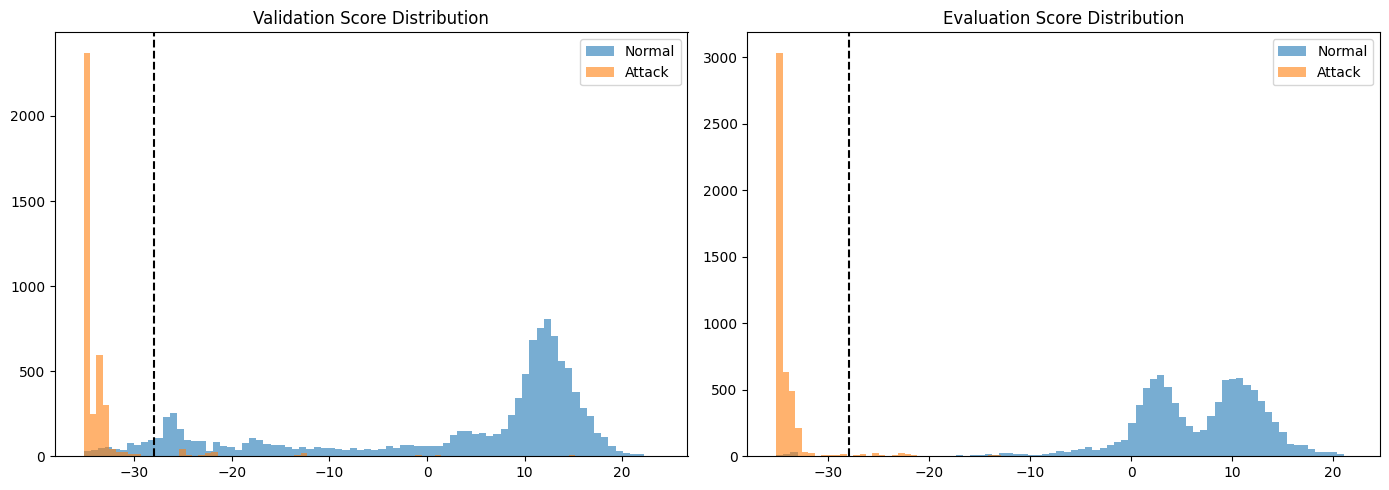

In [31]:
# =============================================================================
#  DISTRIBUTION PLOTS (VAL + EVAL)
# =============================================================================
val_normal = osvm_best_val_scores[y_val.values == 0]
val_attack = osvm_best_val_scores[y_val.values == 1]

eval_normal = osvm_eval_scores[y_eval.values == 0]
eval_attack = osvm_eval_scores[y_eval.values == 1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── VAL DISTRIBUTION ─────────────────────────────
axes[0].hist(val_normal, bins=80, alpha=0.6, label="Normal")
axes[0].hist(val_attack, bins=80, alpha=0.6, label="Attack")
# axes[0].axvline(30, color="black", linestyle="--")
axes[0].axvline(osvm_best_threshold, color="black", linestyle="--")
axes[0].set_title("Validation Score Distribution")
axes[0].legend()

# ── EVAL DISTRIBUTION ────────────────────────────
axes[1].hist(eval_normal, bins=80, alpha=0.6, label="Normal")
axes[1].hist(eval_attack, bins=80, alpha=0.6, label="Attack")
# axes[1].axvline(30, color="black", linestyle="--")
axes[1].axvline(osvm_best_threshold, color="black", linestyle="--")
axes[1].set_title("Evaluation Score Distribution")
axes[1].legend()

plt.tight_layout()
plt.show()


HYBRID ENSEMBLE - HARD VOTING (2/3 RULE)

 FINAL HYBRID ENSEMBLE RESULTS
              precision    recall  f1-score   support

           0     0.9887    0.9912    0.9899     10213
           1     0.9807    0.9753    0.9780      4693

    accuracy                         0.9862     14906
   macro avg     0.9847    0.9832    0.9840     14906
weighted avg     0.9862    0.9862    0.9862     14906

Precision : 0.9807
Recall    : 0.9753
F1-score  : 0.9780
ROC-AUC   : 0.9904
Avg Prec  : 0.9792

Confusion Matrix:
[[10123    90]
 [  116  4577]]


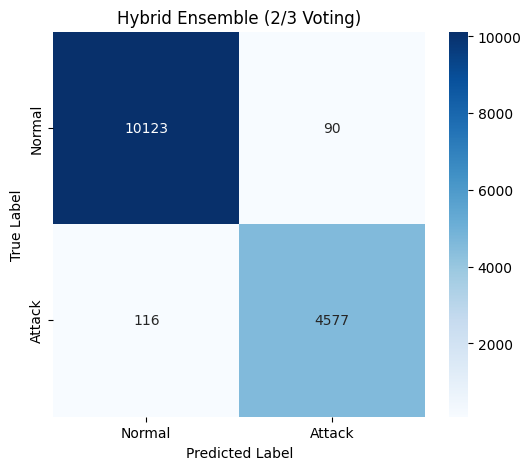

In [32]:
# =============================================================================
# HYBRID ENSEMBLE (2 OUT OF 3 HARD VOTING)
# =============================================================================
print("\n" + "="*60)
print("HYBRID ENSEMBLE - HARD VOTING (2/3 RULE)")
print("="*60)

import numpy as np
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

# ─────────────────────────────────────────────────────────────
# COLLECT PREDICTIONS
# ─────────────────────────────────────────────────────────────

# Ensure all are numpy arrays
if_pred_ens  = np.array(if_y_pred)
osvm_pred_ens = np.array(osvm_y_pred)
ae_pred_ens   = np.array(y_pred_ae)

# ─────────────────────────────────────────────────────────────
# HARD VOTING (SUM OF ATTACK VOTES)
# ─────────────────────────────────────────────────────────────

vote_sum = (
    if_pred_ens +
    osvm_pred_ens +
    ae_pred_ens
)

# 2 or more models say attack → final attack
hybrid_pred = (vote_sum >= 2).astype(int)

# ─────────────────────────────────────────────────────────────
# OPTIONAL: SOFT SCORE (for ROC / AP)
# ─────────────────────────────────────────────────────────────

# average anomaly confidence
hybrid_score = vote_sum / 3.0

# ─────────────────────────────────────────────────────────────
# METRICS
# ─────────────────────────────────────────────────────────────

hybrid_prec = precision_score(y_eval, hybrid_pred, zero_division=0)
hybrid_rec  = recall_score(y_eval, hybrid_pred, zero_division=0)
hybrid_f1   = f1_score(y_eval, hybrid_pred, zero_division=0)

hybrid_roc  = roc_auc_score(y_eval, hybrid_score)
hybrid_ap   = average_precision_score(y_eval, hybrid_score)

hybrid_cm = confusion_matrix(y_eval, hybrid_pred)

# ─────────────────────────────────────────────────────────────
# RESULTS
# ─────────────────────────────────────────────────────────────
print("\n" + "="*50)
print(" FINAL HYBRID ENSEMBLE RESULTS")
print("="*50)

print(classification_report(y_eval, hybrid_pred, digits=4))

print(f"Precision : {hybrid_prec:.4f}")
print(f"Recall    : {hybrid_rec:.4f}")
print(f"F1-score  : {hybrid_f1:.4f}")
print(f"ROC-AUC   : {hybrid_roc:.4f}")
print(f"Avg Prec  : {hybrid_ap:.4f}")

print("\nConfusion Matrix:")
print(hybrid_cm)

# ─────────────────────────────────────────────────────────────
# HEATMAP
# ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,5))
sns.heatmap(
    hybrid_cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Normal', 'Attack'],
    yticklabels=['Normal', 'Attack']
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Hybrid Ensemble (2/3 Voting)")
plt.show()

In [37]:
anomaly_results = {}

anomaly_results["Isolation Forest"] = {
    "Precision": if_prec,
    "Recall": if_rec,
    "F1": if_f1
}

anomaly_results["One-Class SVM"] = {
    "Precision": osvm_prec,
    "Recall": osvm_rec,
    "F1": osvm_f1
}

anomaly_results["Autoencoder"] = {
    "Precision": prec_ae,
    "Recall": rec_ae,
    "F1": f1_ae
}

anomaly_results["Ensemble"] = {
    "Precision": hybrid_prec,
    "Recall": hybrid_rec,
    "F1": hybrid_f1
}

                  Precision    Recall        F1
Isolation Forest   0.983455  0.975282  0.979352
One-Class SVM      0.986108  0.952909  0.969224
Autoencoder        0.945863  0.986576  0.965791
Ensemble           0.980716  0.975282  0.977991


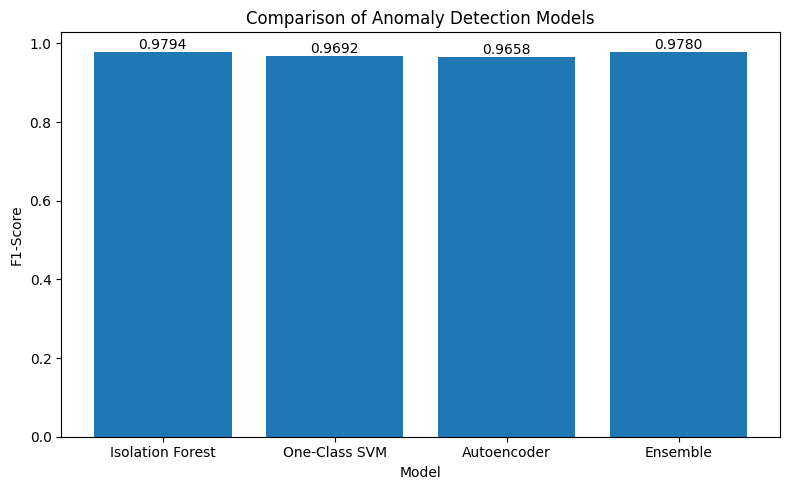

In [38]:
import pandas as pd
import matplotlib.pyplot as plt

# Convert dictionary to DataFrame
df_results = pd.DataFrame(anomaly_results).T

print(df_results)

# F1-score comparison chart
plt.figure(figsize=(8, 5))

bars = plt.bar(
    df_results.index,
    df_results["F1"]
)

plt.title("Comparison of Anomaly Detection Models")
plt.ylabel("F1-Score")
plt.xlabel("Model")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:.4f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()